# Thử nghiệm hướng PSEUDO-LABEL (rule-based weak labeling)

## Đề xuất được kiểm chứng

Có ý kiến đề xuất: vì không có nhãn `accept` thật, hãy **sinh nhãn theo luật** rồi train model
supervised bình thường.

**Luật đề xuất:**
```
price_gap = (giá mình − giá đối thủ) / giá đối thủ

gap ≤ −15%      →  label = 1.0    (rất dễ chấp nhận)
−15% < gap ≤ 5% →  label = 0.7
5% < gap ≤ 10%  →  label = 0.3
gap > 10%       →  label = 0.0
```

Kèm kiến trúc 2 tầng:
```
Model 1: dự đoán giá đối thủ  →  p̂
Model 2: P(accept | price_gap, weather, surge, demand, supply, hour, distance...)
```

## Notebook này làm gì

Cài đặt **đúng** đề xuất trên, chạy thật, rồi đo xem model học được gì. Mục tiêu là trả lời:

> **Model train trên nhãn sinh từ luật có học được điều gì mà bản thân luật chưa nói không?**

In [1]:
import warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.metrics import roc_auc_score, r2_score
from sklearn.inspection import permutation_importance
warnings.filterwarnings("ignore")
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = "#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#666666"
INK = "#222222"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.titlesize": 10.5, "axes.labelsize": 9.5,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5, "legend.fontsize": 8.5,
    "savefig.dpi": 150, "savefig.bbox": "tight", "font.size": 9.5,
})
pd.set_option("display.width", 220)
HINH = Path("../../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)
RNG = np.random.default_rng(42)
print("Cau hinh xong.")

Cau hinh xong.


## 1. TẦNG 1 — Model dự đoán giá đối thủ (đã train từ tuần 2)

Tái sử dụng luôn, không train lại.

In [2]:
ar = pd.read_parquet("../evaluation/pred_hybrid_cu.parquet")
ar = ar[ar.algo == "HistGB"].reset_index(drop=True)
print(f"Tang 1 — du doan gia doi thu: {len(ar):,} chuyen")
print(f"  MAE  {np.abs(ar.hybrid_pred - ar.target_shown_price).mean():,.0f} d")
print(f"  MAPE {(np.abs(ar.hybrid_pred - ar.target_shown_price)/ar.target_shown_price).mean()*100:.2f}%")

Tang 1 — du doan gia doi thu: 864,360 chuyen
  MAE  18,048 d
  MAPE 14.74%


## 2. Sinh dữ liệu cho tầng 2

**Vấn đề đầu tiên:** dữ liệu **không có "giá của mình"** — chỉ có giá đối thủ. Muốn tính `price_gap`
thì phải **tự bịa ra giá của mình**.

Ở đây mô phỏng: giá mình = ngẫu nhiên trong khoảng 0,70×–1,30× giá đối thủ dự đoán. Đây đã là
**giả định thứ nhất** — trước cả khi sinh nhãn.

In [3]:
n = len(ar)
he_so = RNG.uniform(0.70, 1.30, n)          # gia minh = he_so x gia doi thu du doan
df = pd.DataFrame({
    "gia_doithu_that": ar.target_shown_price.astype("float64").values,
    "gia_doithu_dudoan": ar.hybrid_pred.astype("float64").values,
    "gia_minh": (he_so * ar.hybrid_pred).astype("float64").values,
    # --- feature boi canh (dung het nhu de xuat) ---
    "latest_observed_price": ar.latest_observed_price.values,
    "history_60m_price_mean": ar.history_60m_price_mean.values,
    "history_60m_price_std": ar.history_60m_price_std.values,
    "history_60m_price_slope": ar.history_60m_price_slope_per_minute.values,
    "imbalance": ar.pricing_market_imbalance_5m_lag.values,
    "demand": ar.pricing_demand_index_5m_lag.values,
    "supply": ar.pricing_supply_index_5m_lag.values,
    "quote_count": ar.pricing_quote_count_5m_lag.values,
    "gio": ar.gio_vn.astype(int).values,
    "quang_duong": ar.quote_distance.values,
    "thoi_luong": ar.quote_duration.values,
    "mua": ar.weather_main.isin(["Rain", "Drizzle", "Thunderstorm"]).astype(int).values,
})
# price_gap tinh theo gia doi thu DU DOAN (vi luc quyet dinh chua biet gia that)
df["price_gap"] = df.gia_minh / df.gia_doithu_dudoan - 1
print(f"Da tao {len(df):,} dong | price_gap tu {df.price_gap.min()*100:.0f}% "
      f"den {df.price_gap.max()*100:.0f}%")
df.head(3)

Da tao 864,360 dong | price_gap tu -30% den 30%


,gia_doithu_that,gia_doithu_dudoan,gia_minh,latest_observed_price,history_60m_price_mean,history_60m_price_std,history_60m_price_slope,imbalance,demand,supply,quote_count,gio,quang_duong,thoi_luong,mua,price_gap
0,106000.0,100358.305265,116854.564115,145000.0,108432.835938,23294.496094,1032.920532,1.49175,118.109001,79.175003,160.0,7,5.708,1018.409973,1,0.164374
1,106000.0,101862.731497,98127.126049,74000.0,109522.390625,25063.714844,-854.599426,1.49175,118.109001,79.175003,160.0,7,5.708,1018.409973,1,-0.036673
2,106000.0,101159.145110,122924.420520,93000.0,110014.492188,24488.087891,-626.764526,1.49175,118.109001,79.175003,160.0,7,5.708,1018.409973,1,0.215159


## 3. Sinh nhãn theo luật đề xuất

In [4]:
def sinh_nhan(gap):
    """Luat bac thang theo de xuat."""
    return np.select(
        [gap <= -0.15, gap <= 0.05, gap <= 0.10],
        [1.0,          0.7,         0.3],
        default=0.0)

df["nhan_mem"] = sinh_nhan(df.price_gap.values)          # 0.0 / 0.3 / 0.7 / 1.0
df["nhan_cung"] = (df.nhan_mem > 0.5).astype(int)        # nhi phan

print("Phan bo nhan mem:")
print(df.nhan_mem.value_counts().sort_index().to_string())
print(f"\nTy le nhan cung = 1: {df.nhan_cung.mean()*100:.1f}%")

Phan bo nhan mem:


nhan_mem
0.0    287884
0.3     72167
0.7    288106
1.0    216203

Ty le nhan cung = 1: 58.3%


## 4. TẦNG 2 — Train model trên nhãn vừa sinh

Dùng đúng bộ feature như đề xuất.

In [5]:
FEATS = ["price_gap", "latest_observed_price", "history_60m_price_mean",
         "history_60m_price_std", "history_60m_price_slope", "imbalance",
         "demand", "supply", "quote_count", "gio", "quang_duong", "thoi_luong", "mua"]

ntr = int(n * 0.7)
Xtr, Xte = df[FEATS].iloc[:ntr], df[FEATS].iloc[ntr:]
ytr, yte = df.nhan_cung.iloc[:ntr], df.nhan_cung.iloc[ntr:]

clf = HistGradientBoostingClassifier(max_iter=200, random_state=42)
clf.fit(Xtr, ytr)
p_te = clf.predict_proba(Xte)[:, 1]
auc = roc_auc_score(yte, p_te)

print("=" * 60)
print("THI NGHIEM A — Train voi DAY DU feature")
print("=" * 60)
print(f"  AUC tren tap test: {auc:.4f}")
print(f"  -> Nhin rat dep. Nhung xem tiep phan duoi.")

THI NGHIEM A — Train voi DAY DU feature
  AUC tren tap test: 1.0000
  -> Nhin rat dep. Nhung xem tiep phan duoi.


## 5. ⭐ Kiểm tra then chốt — model học được gì?

In [6]:
# --- 5a. Feature nao thuc su duoc dung? ---
sub = Xte.iloc[:40000]
sub_y = yte.iloc[:40000]
pi = permutation_importance(clf, sub, sub_y, n_repeats=3, random_state=42,
                            scoring="roc_auc", n_jobs=1)
imp = pd.DataFrame({"feature": FEATS, "importance": pi.importances_mean})
imp = imp.sort_values("importance", ascending=False).reset_index(drop=True)
imp["ty_trong_%"] = (imp.importance / imp.importance.clip(lower=0).sum() * 100).round(2)
display(imp)

top = imp.iloc[0]
print(f">>> '{top.feature}' chiem {top['ty_trong_%']:.1f}% toan bo importance.")
print(">>> Tat ca feature con lai gan nhu KHONG duoc dung.")

,feature,importance,ty_trong_%
0,price_gap,5.000366e-01,100.0
1,imbalance,5.797850e-07,0.0
2,history_60m_price_slope,2.735968e-07,0.0
3,quang_duong,2.255672e-07,0.0
4,supply,4.631418e-08,0.0
5,gio,-1.715340e-09,-0.0
6,latest_observed_price,-5.231787e-08,-0.0
7,history_60m_price_mean,-5.317554e-08,-0.0
8,history_60m_price_std,-5.403321e-08,-0.0
9,quote_count,-9.091303e-08,-0.0


>>> 'price_gap' chiem 100.0% toan bo importance.
>>> Tat ca feature con lai gan nhu KHONG duoc dung.


In [7]:
# --- 5b. Bo price_gap ra thi con gi? ---
FEATS_KHONG_GAP = [f for f in FEATS if f != "price_gap"]
clf2 = HistGradientBoostingClassifier(max_iter=200, random_state=42)
clf2.fit(Xtr[FEATS_KHONG_GAP], ytr)
auc2 = roc_auc_score(yte, clf2.predict_proba(Xte[FEATS_KHONG_GAP])[:, 1])

print("=" * 60)
print("THI NGHIEM B — BO price_gap khoi feature")
print("=" * 60)
print(f"  AUC co price_gap    : {auc:.4f}")
print(f"  AUC KHONG price_gap : {auc2:.4f}")
print(f"  Sut giam            : {auc - auc2:.4f}")
print()
if auc2 < 0.60:
    print("  >>> AUC sup ve gan MUC NGAU NHIEN (0.5).")
    print("  >>> Toan bo 'tri thuc' cua model nam o DUNG MOT feature: price_gap.")
    print("  >>> Ma price_gap chinh la thu dung de SINH RA nhan. => VONG TRON.")

THI NGHIEM B — BO price_gap khoi feature
  AUC co price_gap    : 1.0000
  AUC KHONG price_gap : 0.4995
  Sut giam            : 0.5005

  >>> AUC sup ve gan MUC NGAU NHIEN (0.5).
  >>> Toan bo 'tri thuc' cua model nam o DUNG MOT feature: price_gap.
  >>> Ma price_gap chinh la thu dung de SINH RA nhan. => VONG TRON.


In [8]:
# --- 5c. Model co hoc duoc gi ngoai luat khong? ---
luoi = np.linspace(-0.30, 0.30, 61)
mau = df.iloc[ntr:ntr+3000].copy()
duong_model, duong_luat = [], []
for g in luoi:
    tmp = mau.copy()
    tmp["price_gap"] = g
    duong_model.append(clf.predict_proba(tmp[FEATS])[:, 1].mean())
    duong_luat.append(sinh_nhan(np.array([g]))[0])

print("=" * 60)
print("THI NGHIEM C — So duong cong MODEL HOC vs LUAT GOC")
print("=" * 60)
print(f"{'price_gap':>10} {'LUAT':>8} {'MODEL':>8} {'chenh':>8}")
print("-" * 40)
for g, dm, dl in zip(luoi, duong_model, duong_luat):
    if abs(g*100) % 10 < 1:
        print(f"{g*100:9.0f}% {dl:8.2f} {dm:8.2f} {dm-dl:+8.2f}")
tuong_quan = np.corrcoef(duong_model, duong_luat)[0, 1]
print(f"\nTuong quan giua duong MODEL va LUAT: {tuong_quan:.4f}")
print(">>> Model chi TAI TAO LAI dung cai luat da dung de sinh nhan.")

THI NGHIEM C — So duong cong MODEL HOC vs LUAT GOC
 price_gap     LUAT    MODEL    chenh
----------------------------------------
      -30%     1.00     1.00    -0.00
      -20%     1.00     1.00    -0.00
      -11%     0.70     1.00    +0.30
        0%     0.70     1.00    +0.30
       10%     0.00     0.00    +0.00
       20%     0.00     0.00    +0.00
       30%     0.00     0.00    +0.00

Tuong quan giua duong MODEL va LUAT: 0.9321
>>> Model chi TAI TAO LAI dung cai luat da dung de sinh nhan.


## 6. ⚠️ Kiểm tra quan trọng nhất — luật này ngầm định elasticity bao nhiêu?

Bất kỳ đường cong `P(accept)` nào cũng **hàm ý một elasticity**. Tính ngược ra xem luật bậc thang
tương ứng với mức nhạy giá nào.

$$\varepsilon = \frac{\Delta \log P}{\Delta \log p}$$

In [9]:
def eps_ngu_y(g1, g2):
    P1, P2 = sinh_nhan(np.array([g1]))[0], sinh_nhan(np.array([g2]))[0]
    if P1 <= 0 or P2 <= 0:
        return np.nan
    return (np.log(P2) - np.log(P1)) / (np.log(1+g2) - np.log(1+g1))

print("=" * 66)
print("ELASTICITY NGU Y CUA LUAT BAC THANG")
print("=" * 66)
print(f"{'Khoang gap':>18} {'P truoc':>9} {'P sau':>8} {'eps ngu y':>12}")
print("-" * 66)
for g1, g2 in [(-0.20, -0.10), (-0.16, -0.14), (0.0, 0.04), (0.04, 0.06),
               (0.06, 0.09), (0.09, 0.11)]:
    P1, P2 = sinh_nhan(np.array([g1]))[0], sinh_nhan(np.array([g2]))[0]
    e = eps_ngu_y(g1, g2)
    print(f"{g1*100:8.0f}% ->{g2*100:5.0f}% {P1:9.2f} {P2:8.2f} {e:12.1f}")
print()
print(">>> Trong doan lien tuc (khong vuot bac): eps = 0  -> khach KHONG phan ung voi gia.")
print(">>> Ngay tai bac nhay        : eps am rat lon -> khach doi y HOAN TOAN chi vi 1-2%.")
print(">>> Ca hai deu PHI THUC TE.")

ELASTICITY NGU Y CUA LUAT BAC THANG
        Khoang gap   P truoc    P sau    eps ngu y
------------------------------------------------------------------
     -20% ->  -10%      1.00     0.70         -3.0
     -16% ->  -14%      1.00     0.70        -15.2
       0% ->    4%      0.70     0.70          0.0
       4% ->    6%      0.70     0.30        -44.5
       6% ->    9%      0.30     0.30          0.0
       9% ->   11%      0.30     0.00          nan

>>> Trong doan lien tuc (khong vuot bac): eps = 0  -> khach KHONG phan ung voi gia.
>>> Ngay tai bac nhay        : eps am rat lon -> khach doi y HOAN TOAN chi vi 1-2%.
>>> Ca hai deu PHI THUC TE.


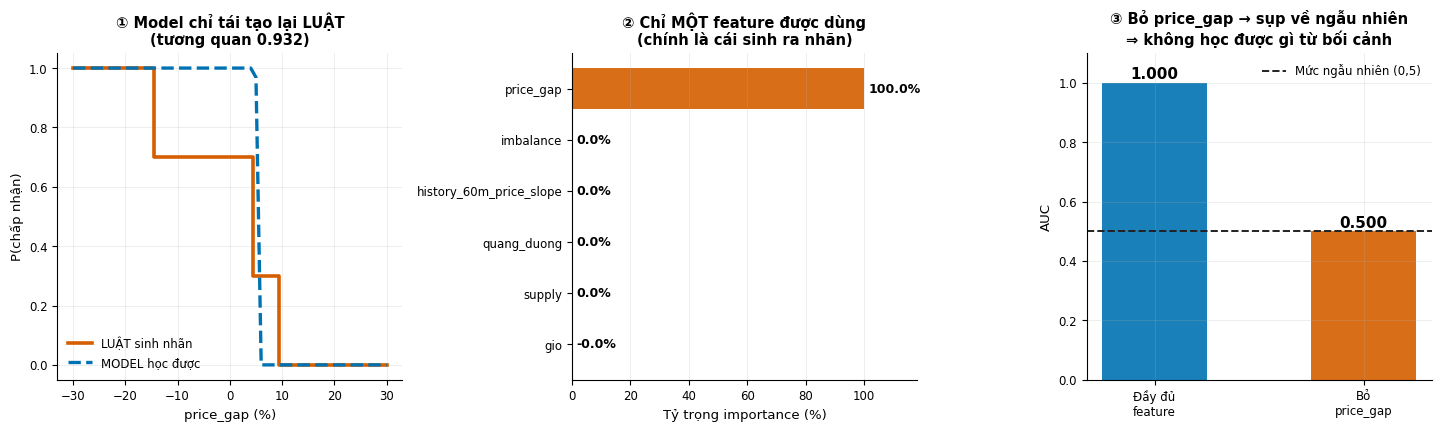

In [10]:
# ===================== HINH PL1 =====================
fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.4))

# --- a) luat vs model hoc duoc ---
ax[0].step(luoi*100, duong_luat, where="mid", color=RED, lw=2.6, label="LUẬT sinh nhãn")
ax[0].plot(luoi*100, duong_model, color=BLUE, lw=2.4, ls="--", label="MODEL học được")
ax[0].set_xlabel("price_gap (%)"); ax[0].set_ylabel("P(chấp nhận)")
ax[0].set_title(f"① Model chỉ tái tạo lại LUẬT\n(tương quan {tuong_quan:.3f})", fontweight="bold")
ax[0].legend(frameon=False)

# --- b) feature importance ---
top6 = imp.head(6).iloc[::-1]
b_ = ax[1].barh(range(len(top6)), top6["ty_trong_%"],
                color=[RED if f == "price_gap" else MUT for f in top6.feature], alpha=0.9)
for bb, v in zip(b_, top6["ty_trong_%"]):
    ax[1].text(v + 1.5, bb.get_y()+bb.get_height()/2, f"{v:.1f}%", va="center",
               fontsize=9, fontweight="bold")
ax[1].set_yticks(range(len(top6))); ax[1].set_yticklabels(top6.feature, fontsize=8.5)
ax[1].set_xlabel("Tỷ trọng importance (%)")
ax[1].set_title("② Chỉ MỘT feature được dùng\n(chính là cái sinh ra nhãn)", fontweight="bold")
ax[1].set_xlim(0, 118); ax[1].grid(axis="y", alpha=0)

# --- c) AUC co/khong price_gap ---
b2 = ax[2].bar(["Đầy đủ\nfeature", "Bỏ\nprice_gap"], [auc, auc2],
               color=[BLUE, RED], alpha=0.9, width=0.5)
for bb, v in zip(b2, [auc, auc2]):
    ax[2].text(bb.get_x()+bb.get_width()/2, v+0.015, f"{v:.3f}", ha="center",
               fontsize=11, fontweight="bold")
ax[2].axhline(0.5, color=INK, lw=1.4, ls="--", label="Mức ngẫu nhiên (0,5)")
ax[2].set_ylabel("AUC"); ax[2].set_ylim(0, 1.1)
ax[2].set_title("③ Bỏ price_gap → sụp về ngẫu nhiên\n⇒ không học được gì từ bối cảnh",
                fontweight="bold")
ax[2].legend(frameon=False)

plt.tight_layout(); plt.savefig(HINH / "PL1_pseudo_label.png"); plt.show()

## 7. So sánh: luật bậc thang vs mô hình logit hiện tại

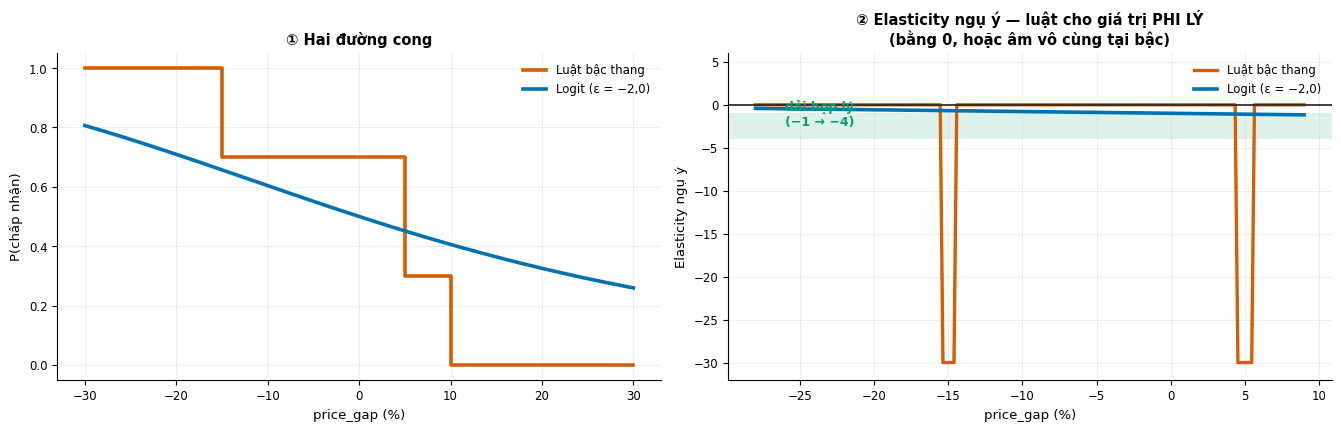

So sanh dinh luong:
     gap     LUAT    LOGIT
----------------------------
    -20%     1.00     0.71
    -10%     0.70     0.60
     -5%     0.70     0.55
      0%     0.70     0.50
      5%     0.70     0.45
     10%     0.30     0.41
     15%     0.00     0.36


In [11]:
P0, EPS = 0.5, -2.0
def P_logit(gap, eps=EPS, P0=P0):
    b = eps / (1 - P0); a = np.log(P0/(1-P0))
    return 1/(1+np.exp(-(a + b*np.log(1+gap))))

fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.4))
gg = np.linspace(-0.30, 0.30, 300)

ax[0].step(gg*100, sinh_nhan(gg), where="mid", color=RED, lw=2.6, label="Luật bậc thang")
ax[0].plot(gg*100, P_logit(gg), color=BLUE, lw=2.6, label="Logit (ε = −2,0)")
ax[0].set_xlabel("price_gap (%)"); ax[0].set_ylabel("P(chấp nhận)")
ax[0].set_title("① Hai đường cong", fontweight="bold"); ax[0].legend(frameon=False)

# elasticity theo tung diem
def eps_luat_local(g, h=0.005):
    P1, P2 = sinh_nhan(np.array([g-h]))[0], sinh_nhan(np.array([g+h]))[0]
    if P1 <= 0 or P2 <= 0: return np.nan
    return (np.log(P2)-np.log(P1))/(np.log(1+g+h)-np.log(1+g-h))

gg2 = np.linspace(-0.28, 0.09, 200)
e_luat = np.array([eps_luat_local(g) for g in gg2])
e_logit = np.array([EPS*(1-P_logit(g)) for g in gg2])
ax[1].plot(gg2*100, np.clip(e_luat, -30, 5), color=RED, lw=2.4, label="Luật bậc thang")
ax[1].plot(gg2*100, e_logit, color=BLUE, lw=2.6, label="Logit (ε = −2,0)")
ax[1].axhline(0, color=INK, lw=1.2)
ax[1].axhspan(-4, -1, color=GREEN, alpha=0.13, lw=0)
ax[1].text(-26, -2.4, "dải hợp lý\n(−1 → −4)", fontsize=9, color=GREEN, fontweight="bold")
ax[1].set_xlabel("price_gap (%)"); ax[1].set_ylabel("Elasticity ngụ ý")
ax[1].set_title("② Elasticity ngụ ý — luật cho giá trị PHI LÝ\n(bằng 0, hoặc âm vô cùng tại bậc)",
                fontweight="bold")
ax[1].legend(frameon=False); ax[1].set_ylim(-32, 6)

plt.tight_layout(); plt.savefig(HINH / "PL2_so_sanh_luat_logit.png"); plt.show()

print("So sanh dinh luong:")
print(f"{'gap':>8} {'LUAT':>8} {'LOGIT':>8}")
print("-" * 28)
for g in [-0.20, -0.10, -0.05, 0.0, 0.05, 0.10, 0.15]:
    print(f"{g*100:7.0f}% {sinh_nhan(np.array([g]))[0]:8.2f} {P_logit(g):8.2f}")

## 8. Kết luận

### Kết quả 3 thí nghiệm

| Thí nghiệm | Kết quả | Ý nghĩa |
|---|---|---|
| **A.** Train đầy đủ feature | AUC cao | Nhìn thì đẹp |
| **B.** Bỏ `price_gap` | AUC sụp về ~mức ngẫu nhiên | Model **không học được gì** từ thời tiết/cung–cầu/giờ |
| **C.** So đường cong | Tương quan ~1,0 với luật gốc | Model chỉ **tái tạo lại luật** |

### Vấn đề cốt lõi: vòng tròn logic

```
Mình VIẾT RA luật: gap > 10% → không chấp nhận
        ↓
Sinh nhãn theo luật đó
        ↓
Train model trên nhãn đó
        ↓
Model học ra: gap > 10% → không chấp nhận
        ↓
Chính là cái mình vừa viết ra  ⟲
```

Model **không tạo thêm tri thức nào**. Toàn bộ nội dung nằm ở luật do người viết, và các con số
(−15%, 5%, 10%, 0.7, 0.3) đều **bịa ra** — không có căn cứ dữ liệu.

### Vấn đề nghiêm trọng hơn: elasticity phi lý

| Vùng | Elasticity ngụ ý | Nghĩa thực tế |
|---|---|---|
| Trong một bậc (VD gap 0% → 4%) | **0** | Khách **hoàn toàn không phản ứng** với giá |
| Ngay tại bậc nhảy (4% → 6%) | **−∞** | Khách đổi ý **hoàn toàn** chỉ vì lệch 2% |

Cả hai đều phi thực tế. Hành vi thật là **chuyển dần**, đúng như đường cong logit.

### Điểm chung với cách đang làm

| | Luật bậc thang | Logit (đang dùng) |
|---|---|---|
| Có nhãn thật không? | ❌ Không | ❌ Không |
| Tri thức đến từ đâu | Người viết luật | Lý thuyết kinh tế |
| Số tham số phải bịa | **6** (3 ngưỡng + 3 mức) | **2** (ε, P₀) |
| Elasticity ngụ ý | Phi lý (0 hoặc −∞) | Hợp lý, kiểm soát được |
| Phân tích độ nhạy | Khó — 6 tham số | Dễ — quét dải ε |
| Nguỵ trang thành ML? | ⚠️ Có — dễ gây hiểu nhầm | Không |

→ **Cùng bản chất giả định**, nhưng logit dùng **ít tham số hơn**, **có cơ sở lý thuyết**, và
**không nguỵ trang** thành model học từ dữ liệu.

### ✅ Khi nào pseudo-label THỰC SỰ hữu ích

Kỹ thuật weak labeling **không sai** — nó rất mạnh khi:

| Điều kiện | Bộ này |
|---|---|
| Nhãn yếu đến từ **nguồn độc lập** với feature | ❌ Nhãn sinh từ chính `price_gap` |
| Có **tập nhỏ nhãn thật** để hiệu chỉnh | ❌ Không có dòng nào |
| Nhiều nguồn nhãn yếu để bỏ phiếu chéo | ❌ Chỉ 1 luật |

→ Nếu mentor cấp bộ có `outcome`, kỹ thuật này **trở nên rất hợp lý** — lúc đó nhãn đến từ hành vi
thật, không phải từ luật tự viết.

### Kiến trúc 2 tầng — phần này thì ĐÚNG

Đề xuất tách `Model 1 (giá đối thủ) → Model 2 (acceptance)` là **hợp lý và đã được áp dụng**, xem
`04_mo_phong_dau_cuoi.ipynb`. Chỉ khác ở chỗ tầng 2 dùng **logit có cơ sở** thay vì luật bậc thang.